# Een verstoord procesensorsignaal ontruisen met PROC LOESS

## Samenvatting

Een oventemperatuursensor op een productielijn wordt tijdens het opstarten elke seconde bemonsterd, waardoor elke meting een langzame niet-lineaire thermische overgang (een snelle opwarmramp, een overshoot die uitdempt, en dan een terugkeer naar het setpoint van 300 °C) combineert met aanzienlijke meetruis. Dit notebook gebruikt **PROC LOESS** om het onderliggende signaal niet-parametrisch terug te winnen. Op de log van 100 metingen selecteerde AICC een afvlakkingsparameter van 0.08 (8 equivalente parameters); de resulterende curve volgt het onderliggende signaal nauwkeurig en laat residuen achter met een standaarddeviatie van 3.10 °C — in essentie de 4 °C ruis die we injecteerden, minus de variantie die de fit verklaart. Ten opzichte van de bekende werkelijke waarden verlaagt de LOESS-schatting de gemiddelde kwadratische fout van 14.77 (ruw) naar 6.63, en een SCORE-stap herbemonstert het ontruiste signaal op een uniform bewakingsraster voor verdere statistische procesbeheersing (SPC).

## Gegevensbronnen

| Dataset | Rijen | Variabelen | Beschrijving |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (verstreken seconden, 0–99), `temp` (waargenomen kamertemperatuur, °C), `truth` (onderliggend ruisvrij signaal, alleen voor validatie) | Synthetisch oven-sensorlog, één meting per seconde. Het onderliggende signaal is een snelle opwarmramp naar een setpoint van 300 °C met een uitdempende overshoot die piekt rond t = 28 (~295 °C), daalt en terugzakt naar het setpoint; de waargenomen `temp` voegt Gaussische meetruis toe (sd ~4 °C). |
| `grid` | 60 | `t` (uniform bewakingsraster 0–99) | Regelmatig tijdraster gebruikt door de SCORE-instructie om een gelijkmatig verdeeld ontruist signaal te leveren voor SPC-grafieken. |

In een productielijn registreert een ovensensor tijdens het opstarten elke seconde de temperatuur. De meting die we vastleggen is de **werkelijke thermische toestand plus meetruis**. De werkelijke toestand volgt geen nette parametrische formule — ze loopt op tijdens het opwarmen, schiet voorbij het setpoint, en stabiliseert dan — dus een globale lineaire of polynomiale fit zou een slecht model zijn.

**Lokale regressie (LOESS)** is hiervoor het juiste gereedschap: het past polynomen van lage graad toe op glijdende lokale omgevingen, waardoor een willekeurig glad signaal wordt teruggewonnen zonder dat we de functionele vorm ervan hoeven op te geven. Hier gaan we:

1. Een realistisch ruizig sensorlog van 100 metingen simuleren.
2. `PROC LOESS` zijn eigen afvlakkingsbandbreedte laten kiezen met het AICC-criterium.
3. Een 95%-betrouwbaarheidsband aan het gefitte signaal toevoegen.
4. Het model scoren op een regelmatig raster voor verdere SPC.
5. Kwantificeren hoeveel ruis we hebben verwijderd.

## Stap 1 — Simuleer het sensorlog

We genereren 100 metingen over 0–99 seconden. Het onderliggende signaal `truth` is een snelle opwarmramp naar een setpoint van 300 °C met een uitdempende overshoot — een vorm die geen rechte lijn of enkele polynoom goed vastlegt: het stijgt steil, piekt boven het setpoint rond t = 28, daalt en stabiliseert dan weer. De waargenomen `temp` voegt Gaussische meetruis toe. `call streaminit` legt de seed vast zodat de run reproduceerbaar is.

In [1]:
GEGEVENS sensor;
    CALL streaminit(70421);
    setpoint = 300;
    DOE t = 0 TOT 99;
        /* Onderliggend signaal: snelle opwarmramp + uitdempende overshoot */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Waargenomen meting = werkelijke waarde + meetruis (sd ~4 C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        UITVOER;
    EINDE;
    BEWAREN t TEMP truth;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=sensor(obs=8) noobs label;
    label t='Tijd (s)' TEMP='Temperatuur (C)' truth='Werkelijke waarde';
    TITEL 'Eerste 8 sensormetingen';
UITVOEREN;


                                                Eerste 8 sensormetingen                                                 

Tijd (s)  Temperatuur (C)  Werkelijke waarde
       0     0.1684867131                  0
       1    28.1933107495      32.0778466448
       2    61.6123615699      61.2117857105
       3    85.5053781561       87.643846097
       4   110.5560474248     111.5945193774
       5   136.6368358359     133.2650493509
       6   144.2434193147     152.8394750856
       7   177.8286488692     170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Stap 2 — Bekijk het ruwe signaal

Een snelle spreidingsplot toont het probleem: de onderliggende drift is met het blote oog duidelijk, maar verborgen onder ruis van meting tot meting. We hebben een schatting van de gladde curve nodig, niet de grillige punten.

                                                Eerste 8 sensormetingen                                                 




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


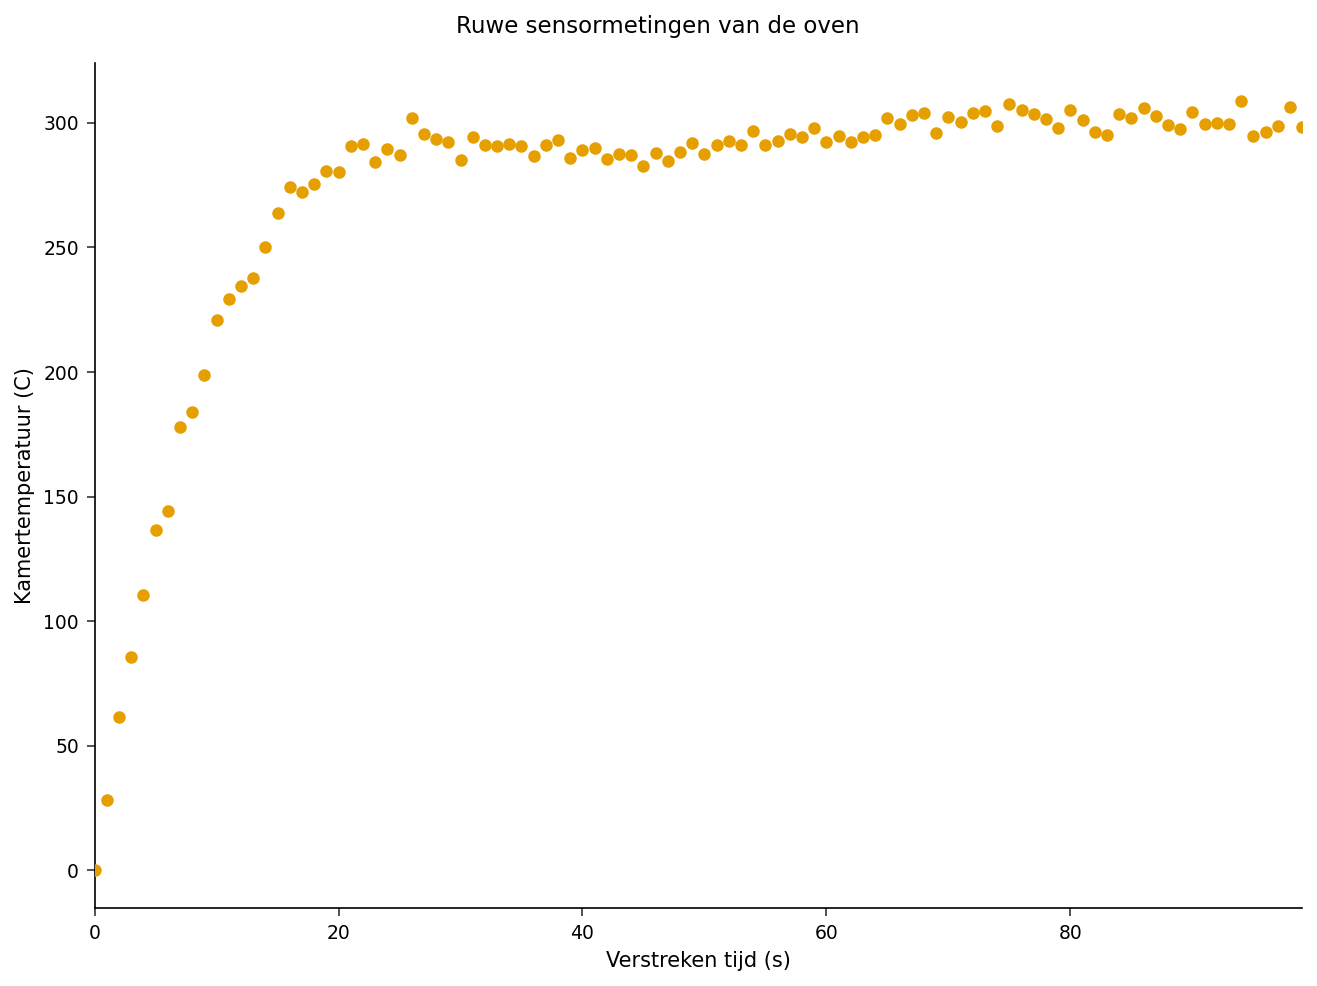

In [2]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT GEGEVENS=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS label='Verstreken tijd (s)';
    YAXIS label='Kamertemperatuur (C)';
    TITEL 'Ruwe sensormetingen van de oven';
UITVOEREN;

ODS GRAPHICS OFF;


## Stap 3 — Fit LOESS met automatische bandbreedteselectie

De afvlakkingsparameter bepaalt hoe breed elke lokale omgeving is: te klein overfit de ruis, te groot wist de overshoot uit. In plaats van te gokken laten we LOESS deze kiezen door het **gecorrigeerde Akaike-informatiecriterium** te minimaliseren met `select=AICC`. We gebruiken lokale kwadratische polynomen (`degree=2`) zodat de curve de kromming van de opwarming en de overshoot kan volgen, en vragen een 95%-betrouwbaarheidsband op met `clm` en `alpha=0.05`.

`ODS OUTPUT` legt twee tabellen vast als datasets: `OutputStatistics` (per-punt gladgestreken waarden en residuen) en `FitSummary` (de geselecteerde bandbreedte en fitdiagnostiek). De `OUTPUT`-instructie schrijft een dataset `fitted` met de voorspelling, het residu en de 95%-betrouwbaarheidsgrenzen voor elke observatie — het ruwe materiaal voor de plots die volgen.

In [3]:
PROCEDURE loess GEGEVENS=sensor;
    ODS OUTPUT OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODEL TEMP = t / DEGREE=2 select=AICC CLM ALPHA=0.05 details;
    UITVOER out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
UITVOEREN;


                                                Eerste 8 sensormetingen                                                 


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Stap 4 — Bekijk het geselecteerde model

De Fit Summary registreert de AICC-optimale afvlakkingsparameter en het spoor van de voorspellingsmatrix (de effectieve vrijheidsgraden — een maat voor modelcomplexiteit). Een kleinere afvlakkingsparameter en grotere DF betekenen een grilligere fit; AICC balanceert fit tegen complexiteit automatisch.

In [4]:
PROCEDURE AFDRUKKEN GEGEVENS=fit_summary noobs label;
    label smoothingparameter='Afvlakkingsparameter' label1='Metriek' nvalue1='Waarde';
    TITEL 'LOESS-samenvatting (door AICC geselecteerde bandbreedte)';
UITVOEREN;


                                LOESS-samenvatting (door AICC geselecteerde bandbreedte)                                

Afvlakkingsparameter                          Metriek          Waarde
                0.08  Residual Sum of Squares          950.8591917253
                0.08  Equivalent Number of Parameters               8
                0.08  Delta1                                        8
                0.08  Delta2                                      7.6
                0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Stap 5 — Leg de fit en betrouwbaarheidsband over de werkelijke waarden

Omdat dit gesimuleerde gegevens zijn, hebben we de ruisvrije kolom `truth` behouden. Door de LOESS-schatting en de 95%-band samen met `truth` te plotten, zien we hoe getrouw de smoother het onderliggende signaal heeft teruggewonnen dat hij nooit direct heeft gezien.

                                LOESS-samenvatting (door AICC geselecteerde bandbreedte)                                




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


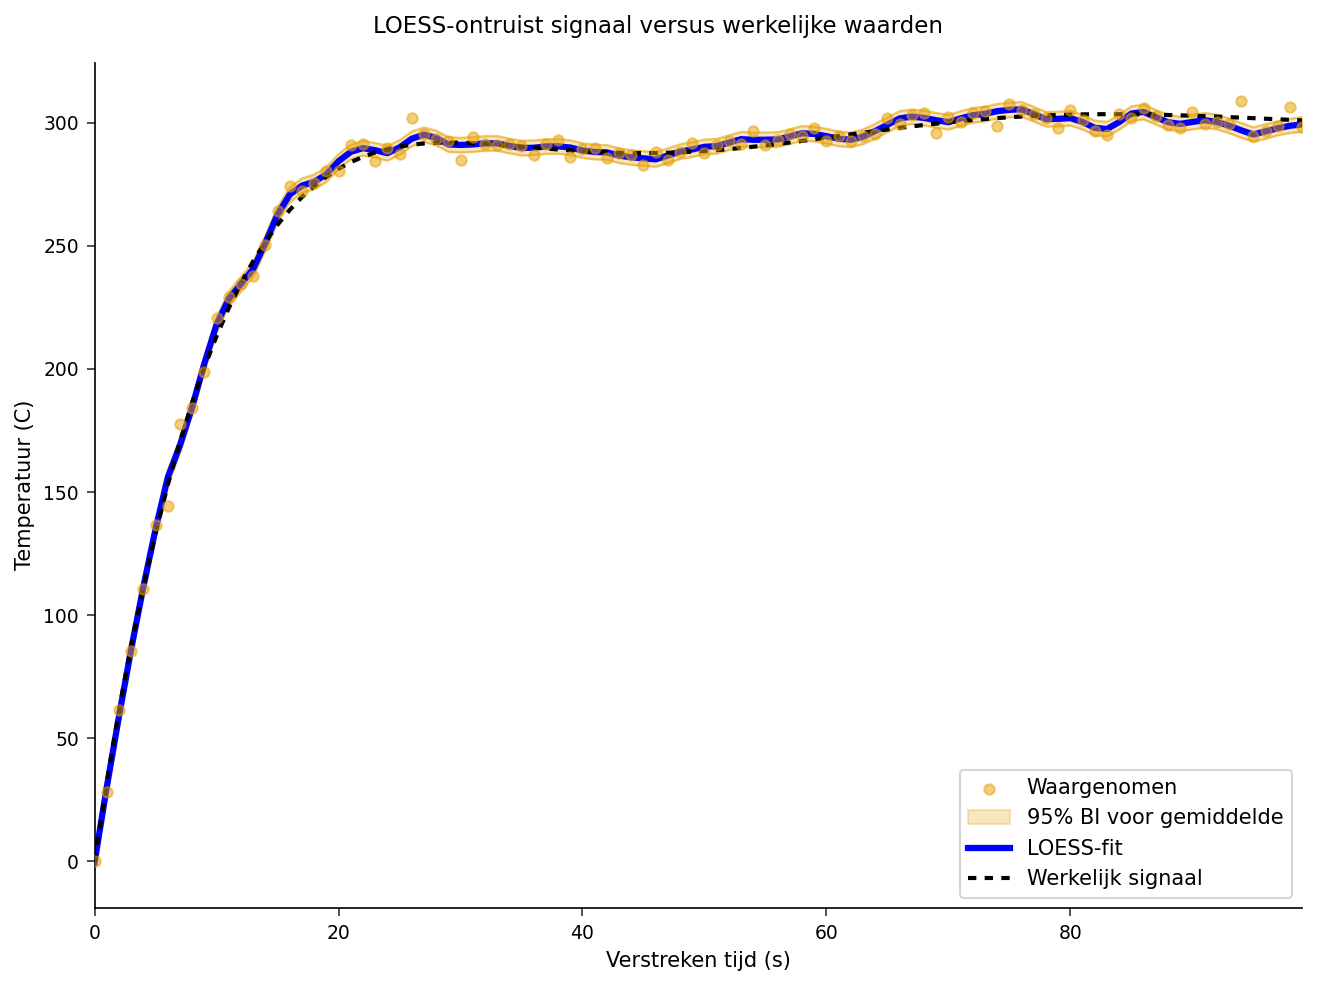

In [5]:
PROCEDURE SORTEREN GEGEVENS=fitted; VOLGENS t; UITVOEREN;

ODS GRAPHICS ON;

PROCEDURE SGPLOT GEGEVENS=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Waargenomen';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='95% BI voor gemiddelde';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='LOESS-fit';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Werkelijk signaal';
    XAXIS label='Verstreken tijd (s)';
    YAXIS label='Temperatuur (C)';
    TITEL 'LOESS-ontruist signaal versus werkelijke waarden';
UITVOEREN;

ODS GRAPHICS OFF;


## Stap 6 — Residudiagnostiek

De residuen (waargenomen min gefit) zouden eruit moeten zien als structuurloze ruis, gecentreerd rond nul. Een overgebleven trend zou wijzen op onderafvlakking of een gemist kenmerk. We plotten de residuen tegen de tijd en vatten hun spreiding samen — de standaarddeviatie van de residuen komt uit op 3.10 °C, iets onder de 4 °C ruis die we injecteerden omdat de lokale fit er een klein deel van absorbeert.

                                LOESS-samenvatting (door AICC geselecteerde bandbreedte)                                

                                      Residusamenvatting (teruggewonnen meetruis)                                       

                                                  The MEANS Procedure

 Variable  Label              N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------------------
 RESID     Residu (C)       100       0.139       3.096     -11.688      11.909
 ------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


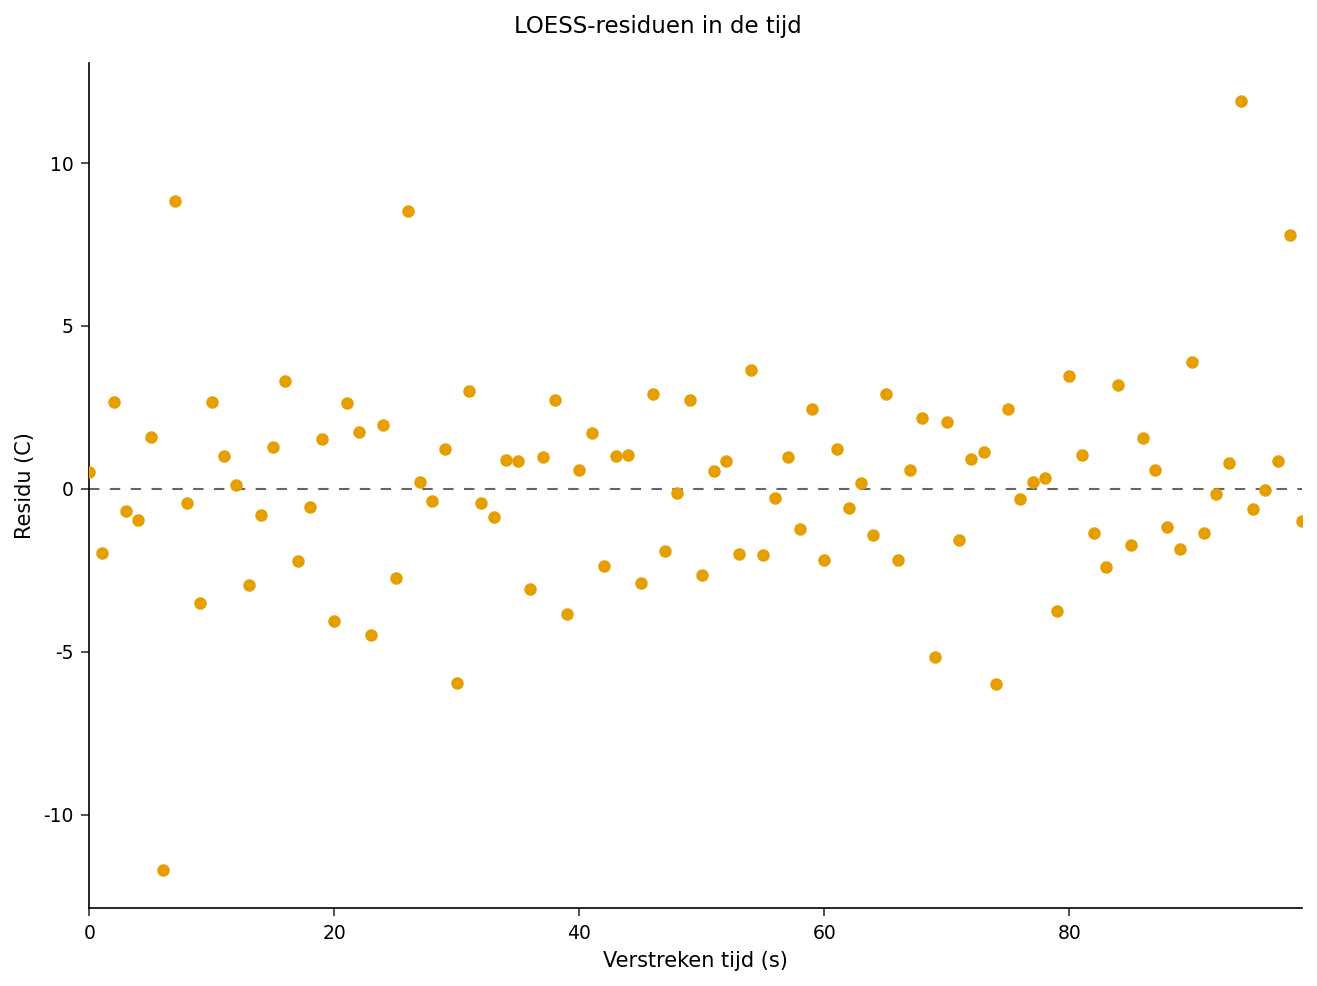

In [6]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT GEGEVENS=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS label='Verstreken tijd (s)';
    YAXIS label='Residu (C)';
    TITEL 'LOESS-residuen in de tijd';
UITVOEREN;

ODS GRAPHICS OFF;

PROCEDURE GEMIDDELDEN GEGEVENS=fitted n mean std MIN MAX maxdec=3;
    label resid='Residu (C)';
    VARIABELE resid;
    TITEL 'Residusamenvatting (teruggewonnen meetruis)';
UITVOEREN;


## Stap 7 — Scoor een regelmatig bewakingsraster voor SPC

De tijdstempels van de sensor hoeven niet gelijkmatig verdeeld te zijn, maar een regelkaart wil het signaal op een vaste cadans. We bouwen een uniform tijdraster van 60 punten en passen het gefitte LOESS-model erop toe met de `SCORE`-instructie, waarbij we betrouwbaarheidsgrenzen opvragen. De gescoorde waarden vormen een schoon, gelijkmatig verdeeld signaal dat klaar is om een SPC-routine te voeden.

In [7]:
GEGEVENS grid;
    DOE t = 0 TOT 99 VOLGENS 99/59;
        UITVOER;
    EINDE;
UITVOEREN;

PROCEDURE loess GEGEVENS=sensor;
    MODEL TEMP = t / DEGREE=2 select=AICC CLM ALPHA=0.05;
    SCORE GEGEVENS=grid CLM AFDRUKKEN;
    TITEL 'LOESS gescoord op een uniform bewakingsraster';
UITVOEREN;


                                      Residusamenvatting (teruggewonnen meetruis)                                       


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Stap 8 — Kwantificeer de ontruising

Ten slotte vergelijken we het ruwe signaal en de LOESS-schatting met de bekende werkelijke waarden. De gemiddelde kwadratische fout van het gladgestreken signaal zou veel kleiner moeten zijn dan die van de ruwe metingen, wat bevestigt dat LOESS de meetruis heeft verwijderd met behoud van de opwarmramp en de overshoot.

In [8]:
GEGEVENS accuracy;
    INSTELLEN fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=accuracy mean maxdec=3;
    VARIABELE raw_sq_err loess_sq_err;
    label raw_sq_err   = 'MSE van ruwe metingen t.o.v. werkelijke waarde'
          loess_sq_err = 'MSE van LOESS-fit t.o.v. werkelijke waarde';
    TITEL 'Ontruisingsprestatie: ruw versus LOESS';
UITVOEREN;


                                         Ontruisingsprestatie: ruw versus LOESS                                         

                                                  The MEANS Procedure

 Variable      Label                                                    Mean
 ---------------------------------------------------------------------------
 raw_sq_err    MSE van ruwe metingen t.o.v. werkelijke waarde         14.774
 loess_sq_err  MSE van LOESS-fit t.o.v. werkelijke waarde              6.629
 ---------------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretatie van de resultaten

- **Automatische bandbreedte.** `select=AICC` koos een afvlakkingsparameter van **0.08** zonder handmatig afstellen, wat neerkomt op ongeveer **8 equivalente parameters** — genoeg lokale flexibiliteit om de opwarming, de overshoot en de dip te volgen, terwijl de ruis toch wordt weggewerkt.
- **Getrouwe terugwinning.** De gefitte curve volgt het onderliggende `truth`-signaal nauwkeurig over de ramp, de overshootpiek rond t = 28 en de stabiliserende staart, wat aantoont dat LOESS een willekeurig niet-lineair signaal heeft teruggewonnen zonder parametrische aannames.
- **Schone residuen.** De residuen verspreiden zich rond nul met een standaarddeviatie van **3.10 °C** (gemiddelde 0.14, bereik −11.7 tot 11.9) en tonen geen overgebleven tijdtrend — bewijs dat het model noch over- noch onderafgevlakt is.
- **Meetbare ontruising.** Ten opzichte van de werkelijke waarden verlaagt de LOESS-schatting de gemiddelde kwadratische fout van **14.77** (ruwe metingen) naar **6.63** — een reductie van 55%, de belangrijkste winst voor procesbewaking.
- **SPC-klare uitvoer.** De SCORE-stap leverde het ontruiste signaal op een uniform raster van 60 punten met betrouwbaarheidsgrenzen, precies de vorm die een regelkaart verderop nodig heeft.

**Conclusie:** Wanneer een procesensor een glad maar ruizig signaal van onbekende vorm produceert, is PROC LOESS een manier met weinig aannames en zelfregelende afstelling om de onderliggende trend te extraheren, onzekerheidsgrenzen toe te voegen en te herbemonsteren op een bewakingsraster — allemaal zonder je vast te leggen op een parametrisch model dat de fysica misschien niet rechtvaardigt.